In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Tarea 1

1.- Realice un notebook en el que se expliquen y programen los siguientes algoritmos de integración de ecuaciones diferenciales: 

    a) Integración con método de Euler.
    b) Integración con método de Runge-Kutta de 2° orden.
    c) Integración con método de Runge-Kutta de 4° orden.

Verifique el funcionamiento de sus integradores encontrando la solución de la siguiente ecuación diferencial para \$x(t)\$:
$$
\ddot{x}+0.5\dot{x} + \sin{x} = e^{-t}(\sin{(3t) + cos{(2t)}})
$$
Con condiciones iniciales \$ \dot{x}(0)=1 \$ y \$x(0)=0\$

In [3]:
def Euler(g,x0,t):
    h = t[1]-t[0]
        #Paso que vamos a considerar entre punto y punto
    sol = np.zeros( (len(x0),len(t)) )
        #Genera un arreglo (listas anidadas) donde hay tantas listas como componentes de x0 (len(x0) listas), compuestas de 
        #len(t) elementos. En ella almacenamos puntos que siguen de manera aproximada la solución de mi ec. diferencial.
    sol[:,0] = x0
        #Asignamos nuestra condición inicial al primer elemento de todas las listas en mi arreglo.
    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + h*g(sol[:,i],t[i])
        #EL ciclo va programando cada punto x_n asignando igual a como lo hicimos en x0; las componentes de x_n se mandan al
        #n'ésimo elemento de cada lista respectivamente. La ecuación utilizada es la vista en clase. Como x0 ya está definido 
        #se hace un ajuste de ínidices en el rango de nuestro ciclo for.
    return sol

def RK2(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        t_med = t[i] + 0.5*h
        sol_med = sol[:,i] + 0.5*h*g(sol[:,i],t[i])
        sol[:,i+1] = sol[:,i] + h*g(sol_med,t_med)
    return sol

def RK4(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0) , len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        k1 = g(sol[:,i],t[i])
        k2 = g(sol[:,i] + 0.5*h*k1 , t[i] + 0.5*h)
        k3 = g(sol[:,i] + 0.5*h*k2 , t[i] + 0.5*h)
        k4 = g(sol[:,i] + h*k2 , t[i] + h)
        sol[:,i+1] = sol[:,i] + (h/6.0)*(k1 + 2.0*k2 + 2.0*k3 + k4)
    return sol


In [4]:
#Objetos necesarias para cada método.

#Como tenemos una derivada de segundo orden y los métodos están planteados para ecuaciones diferenciales de 1er orden hacemos un
#cambio de vaiable x'=v; por lo que x_vx=(x,v).
def g(x_vx,t):
    g1 = x_vx[1]
        #Obtenida de nuestro cambio de variable x'=v
    g2 = -0.5*x_vx[1] - np.sin(x_vx[0]) + np.exp(-1*t)*(np.sin(3*t)+np.cos(2*t))
        #Obtenida al sustituir x'=v en nuestra ec. dif. original
    return np.array( [g1,g2] )

x_vx = np.array([0,1])
t = np.arange(0,8*np.pi,0.01) 
    #No tenemos resticciones con la cantidad de datos, pero sí necesitamos controlar h, por lo que usaremos arrange y no linspace

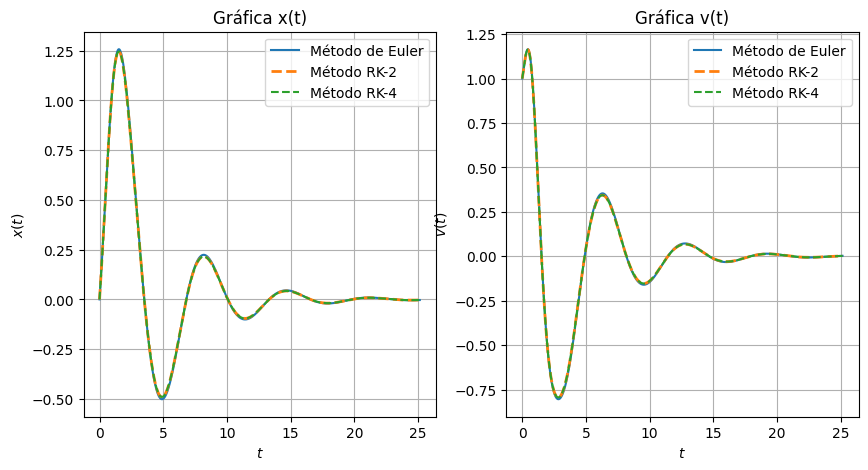

In [5]:
sol_e = Euler(g,x_vx,t)
sol_rk2 = RK2(g,x_vx,t)
sol_rk4 = RK4(g,x_vx,t)

fig , ejes = plt.subplots(1,2,figsize=(10,5))
#Gráfica de x(t)
ejes[0].plot(t,sol_e[0,:],label=r'Método de Euler')
ejes[0].plot(t,sol_rk2[0,:],'--',label=r'Método RK-2',linewidth=2)
ejes[0].plot(t,sol_rk4[0,:],'--',label=r'Método RK-4')
ejes[0].set_title('Gráfica x(t)')
ejes[0].set_xlabel(r'$t$'), ejes[0].set_ylabel(r'$x(t)$')
ejes[0].legend()
ejes[0].grid()

#Gráfica de v(t)
ejes[1].plot(t,sol_e[1,:],label=r'Método de Euler')
ejes[1].plot(t,sol_rk2[1,:],'--',label=r'Método RK-2',linewidth=2)
ejes[1].plot(t,sol_rk4[1,:],'--',label=r'Método RK-4')
ejes[1].set_title('Gráfica v(t)')
ejes[1].set_xlabel(r'$t$'), ejes[1].set_ylabel(r'$v(t)$')
ejes[1].legend()
ejes[1].grid()



2.- Utilizando los integradores anteriores encuentre un paso que le asegure que la solución tenga por lo menos 4 cifras significativas en el resultado de integración. La ecuación es la siguiente:
$$
\dddot{y} + \ddot{y}^2 - 3\dot{y}^3 + \cos^2{y} = e^{-t}\sin{(3t)}
$$
Con condiciones iniciales \$\ddot{y}(1)=1\$, \$\dot{y}(1)=2\$, \$y(1)=1\$. En particular que sucede en el intervalo \$t\in [1,1.65]\$, describa lo que sucede cuando \$t \rightarrow 2\$.

In [9]:
#Para ver las cifras significativas del resultado de integración es necesario compararla con la solución analítica de nuestra
#ecuación diferencial. La ecuación diferencial que estamos tratando no tiene solución explícita, por lo que escogeremos la solución
#dada alguna h y la compararemos con la correspondiente a (h + delta). Utilizaremos el método de Euler

def g2(y_vy_ay,t):
    g1 = y_vy_ay[1]
        #Obtenida de nuestro cambio de variable x'=v
    g2 = y_vy_ay[2]
        #Obtenida al sustituir x'=v en nuestra ec. dif. original
    g3 = -((y_vy_ay[2])**2) + 3*((y_vy_ay[1])**3) - (np.cos(y_vy_ay[0]))**2 + np.exp(-1*t)*np.sin(3*t)
    return np.array( [g1,g2,g3] )

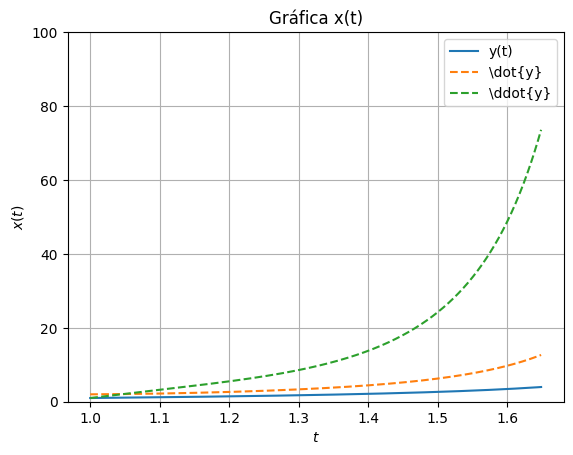

In [65]:
y_vy_ay = np.array([1,2,1])
t1 = np.arange(1,1.65,0.001) #h1=0.01
t2 = np.arange(1,1.65,0.0005) #h2=0.005=(h1)/2

solh1 = RK2(g2,y_vy_ay,t1)
solh2 = RK2(g2,y_vy_ay,t2)

for i in range(len(t1)):                 #Usado para encontrar la h indicada (si teníamos de salida i,a repetíamos el proceso dis-
    a = np.abs(solh1[0,i]-solh2[0,i*2])  #minuyendo h1 una unidad). Encontramos que el paso que
    if a >= 0.0001:
        print(i,a)
        break

plt.plot(t1,solh1[0,:],label=r'y(t)')
plt.plot(t1,solh1[1,:],'--',label=r'\dot{y}')
plt.plot(t1,solh1[2,:],'--',label=r'\ddot{y}')
plt.title('Gráfica x(t)')
plt.xlabel(r'$t$'), plt.ylabel(r'$x(t)$')
plt.ylim(0,100)
plt.legend()
plt.grid()


C:\Users\karla\AppData\Local\Temp\ipykernel_20944\1659601974.py:13: RuntimeWarning: overflow encountered in scalar power
  g3 = -((y_vy_ay[2])**2) + 3*((y_vy_ay[1])**3) - (np.cos(y_vy_ay[0]))**2 + np.exp(-1*t)*np.sin(3*t)
C:\Users\karla\AppData\Local\Temp\ipykernel_20944\1659601974.py:13: RuntimeWarning: invalid value encountered in cos
  g3 = -((y_vy_ay[2])**2) + 3*((y_vy_ay[1])**3) - (np.cos(y_vy_ay[0]))**2 + np.exp(-1*t)*np.sin(3*t)


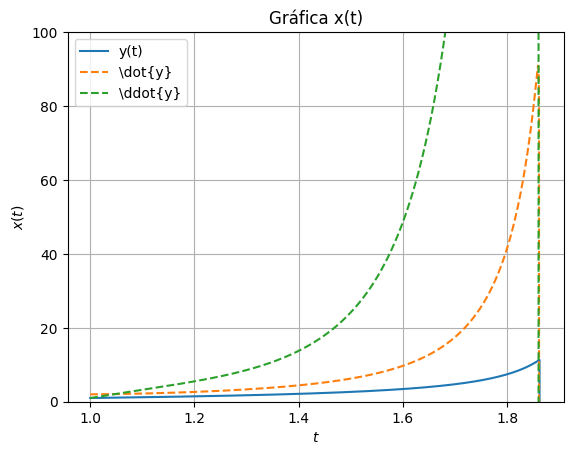

In [66]:
# Veamos qué pasa si t tiende a 2
t1 = np.arange(1,2,0.001) #h1=0.01
solh1 = RK2(g2,y_vy_ay,t1)

plt.plot(t1,solh1[0,:],label=r'y(t)')
plt.plot(t1,solh1[1,:],'--',label=r'\dot{y}')
plt.plot(t1,solh1[2,:],'--',label=r'\ddot{y}')
plt.title('Gráfica x(t)')
plt.xlabel(r'$t$'), plt.ylabel(r'$x(t)$')
plt.ylim(0,100)
plt.legend()
plt.grid()

#Notemos que conforme t se acerca a 2 las gráficas crecen exponencialmente, al igual que la diferencia entre ellas. Al llegar
#a t=2 (y, y', y'') caen a 0 de forma abrupta

3.- Modifique las funciones integradoras en el problema 1 de tal manera que se puedan pasar argumentos opcionales al sistema de ecuaciones diferenciales de tal manera que se puedan modificar parámetros al momento de hacer la integración. Una vez hecho esto, obtenga la solución de la siguiente ecuación diferencial:
$$
\ddot{x} + \frac{1}{10}\dot{x} + 4\sin{(x)}= \frac{1}{2}\sin{(wt)}
$$
Con condiciones iniciales \$ \dot{x}(0)=1 \$, \$x(0)=0\$ y para $w = \{ 1,1.1,1.2,1.3,...,2.9,3 \} $. Realice la gráfica de algunas coluciones que representen el comportamiento de la solución en función de \$w\$ y explique su resultado.

4.- Considere el siguiente sistema de ecuaciones diferenciales:
$$
\begin{align*}
    \frac{dx}{dt}& = 10(y-x)\\
    \frac{dy}{dt}& = x(28-z)-y\\
    \frac{dz}{dt}& = xy - \frac{8}{3}z
\end{align*}
$$
Realice una integración numérica del sistema de ecuaciones con alguno de los integradores del problema 1 (el que más le guste) y realice los soguientes ejercicioes;}: